In [1]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from netCDF4 import Dataset

import iris
import iris.coord_categorisation
import iris.plot as iplt
import iris.quickplot as qplt

import os
import logging

import numpy as np
import numpy.ma as ma

import pickle
from pathlib import Path

from IPython.display import clear_output
import gc

logger = logging.getLogger(__name__)

In [2]:
run plot_tools.ipynb

In [3]:
def average_dict(input):
    output=sum( np.array(input[clim] )[0][:] for clim in ESMS) / 3
    return(output)

In [4]:
def sum_carbon_pools(input):
    output=sum( np.array(input[var] ) [0][:] for var in VARIABLES )
    return(output)

jules
clm
jsbach
orchidee
jules
clm
jsbach
orchidee
clm
jsbach
orchidee
clm
jsbach
orchidee


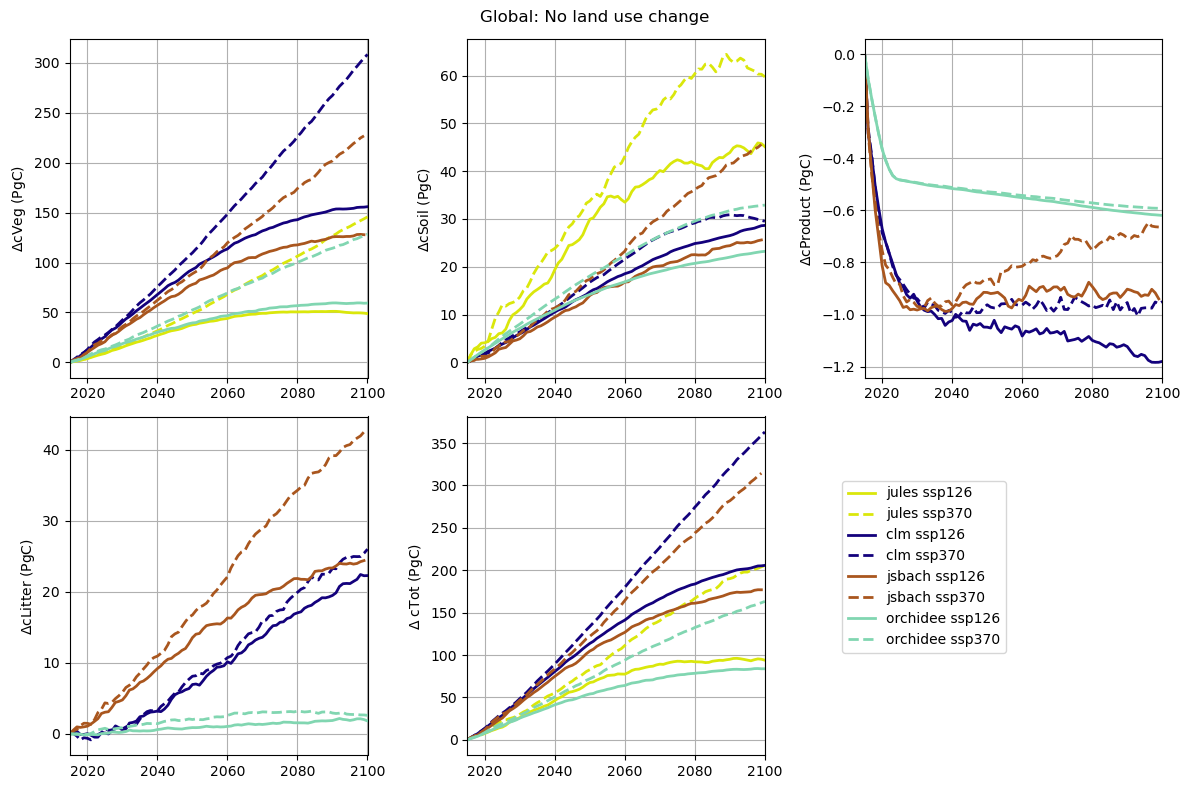

In [16]:
REGIONS=['Global','Tropics','NH-Temperate']
DECADES=['start','2030s','2050s','2090s']
MODELS=['jules','clm','jsbach','orchidee']
LANDUSES=['nolucaff','noluc','agtonat', 'agtoaff','nattoaff']
#SSPS=['ssp126']
SSPS=['ssp126','ssp370']
ESMS=['mpi-esm1-2-hr','ukesm1-0-ll','ipsl-cm6a-lr']
VARIABLES=['cVeg','cSoil','cProduct','cLitter','cTot']

plot_all=False
region='Global'

years = np.arange(2015,2101)     
nyears = len(years)

#Set up plotting stuff
#Each land model needs a different color
fig,axes=plt.subplots(2,3, figsize=[12,8])
fig.suptitle(region+': No land use change',fontsize=12)
ix=0
iy=0

LU_SCENARIO_MEAN = {var: {lsm_mod: {region: {landuse: {ssp_scen: [] for ssp_scen in SSPS} 
                    for landuse in LANDUSES} for region in REGIONS} for lsm_mod in MODELS} 
                    for var in VARIABLES}
LU_SCENARIO_ALL = {var: {lsm_mod: {region: {landuse: {esm: {ssp_scen: [] for ssp_scen in SSPS} 
                    for esm in ESMS} for landuse in LANDUSES} for region in REGIONS} 
                    for lsm_mod in MODELS} for var in VARIABLES}
BOXPLOT_INPUT = {decade: {landuse: {ssp_scen: {vals: [] for vals in range(12)} for ssp_scen in SSPS} 
                for landuse in LANDUSES} for decade in DECADES} 


landuse_exists = {lsm_mod: {landuse: [True] for landuse in LANDUSES} for lsm_mod in MODELS}
landuse_exists['jsbach']['agtonat'] = False
landuse_exists['jsbach']['nattoaff'] = False
landuse_exists['orchidee']['agtobio'] = False
landuse_exists['orchidee']['agtonat'] = False
landuse_exists['orchidee']['nattobio'] = False

variable_exists = {var: {lsm_mod: [True] for lsm_mod in MODELS} for var in VARIABLES}
variable_exists['cProduct']['jules'] = False
variable_exists['cLitter']['jules'] = False


test_mean={ssp: [] for ssp in SSPS}
colors = {model: [] for model in MODELS}

colors['jules'] = '#DAE70B'
colors['clm'] = '#13017C'
colors['jsbach'] = '#A9561E'
colors['orchidee'] = '#81D6B1'
#https://matplotlib.org/stable/users/explain/colors/colors.html

linestyles = {ssp: [] for ssp in SSPS}
linestyles['ssp126'] = '-'
linestyles['ssp370'] = '--'

#cVeg and cSoil are easy
for var in VARIABLES[:-1]:

    # set axes
    ax=axes[iy,ix]
    ax.set_ylabel(r'$\Delta$' +var+' (PgC) ',fontsize=10)
    ax.set_xlim([2015,2100])
    ax.grid(True) 
    
    for model in MODELS:
        #First get no land use change (noluc)
        if variable_exists[var][model]:
            print(model)
            if model=='jules':
                #nolucbio,nolucbio_tr,nolucbio_te = retrieve_data_generic(var,'PgC','nolucbio',model)
                # Only using JULES for the NO LUC experiment. Afforestation experiment has some problems with losing soil carbon 
                # likely due to the additional PFTs.
                nolucaff,nolucaff_tr,nolucaff_te = retrieve_data_generic(var,'PgC','nolucbio',model)
                for ssp in SSPS:
                    LU_SCENARIO_MEAN[var][model]['Global']['noluc'][ssp]=average_dict(nolucaff[ssp])
                    LU_SCENARIO_MEAN[var][model]['Tropics']['noluc'][ssp]=average_dict(nolucaff_tr[ssp])
                    LU_SCENARIO_MEAN[var][model]['NH-Temperate']['noluc'][ssp]=average_dict(nolucaff_te[ssp])
                    for esm in ESMS:
                        LU_SCENARIO_ALL[var][model]['Global']['noluc'][esm][ssp]=nolucaff[ssp][esm][0][:]
                        LU_SCENARIO_ALL[var][model]['Tropics']['noluc'][esm][ssp]=nolucaff_tr[ssp][esm][0][:]
                        LU_SCENARIO_ALL[var][model]['NH-Temperate']['noluc'][esm][ssp]=nolucaff_te[ssp][esm][0][:]
            else:
                if var=='cLitter' and model=='clm':
                    cdata,cdata_tr,cdata_te = retrieve_data_generic(var,'PgC','noluc',model)
                    cwd,cwd_tr,cwd_te = retrieve_data_generic('cCwd','PgC','noluc',model)
                    #litter is small
                    for ssp in SSPS:
                        LU_SCENARIO_MEAN[var][model]['Global']['noluc'][ssp]=average_dict(cwd[ssp]) + average_dict(cdata[ssp])
                        LU_SCENARIO_MEAN[var][model]['Tropics']['noluc'][ssp]=average_dict(cwd_tr[ssp]) + average_dict(cdata_tr[ssp])
                        LU_SCENARIO_MEAN[var][model]['NH-Temperate']['noluc'][ssp]=average_dict(cwd_te[ssp]) + average_dict(cdata_te[ssp])
                        for esm in ESMS:
                            LU_SCENARIO_ALL[var][model]['Global']['noluc'][esm][ssp]=cwd[ssp][esm][0][:] + cdata[ssp][esm][0][:]
                            LU_SCENARIO_ALL[var][model]['Tropics']['noluc'][esm][ssp]=cwd_tr[ssp][esm][0][:] + cdata_tr[ssp][esm][0][:]
                            LU_SCENARIO_ALL[var][model]['NH-Temperate']['noluc'][esm][ssp]=cwd_te[ssp][esm][0][:] + cdata_te[ssp][esm][0][:]                   
                
                else:
                    noluc,noluc_tr,noluc_te = retrieve_data_generic(var,'PgC','noluc',model)
                    for ssp in SSPS:
                        LU_SCENARIO_MEAN[var][model]['Global']['noluc'][ssp]=average_dict(noluc[ssp]) 
                        LU_SCENARIO_MEAN[var][model]['Tropics']['noluc'][ssp]=average_dict(noluc_tr[ssp]) 
                        LU_SCENARIO_MEAN[var][model]['NH-Temperate']['noluc'][ssp]=average_dict(noluc_te[ssp]) 
                        for esm in ESMS:
                            LU_SCENARIO_ALL[var][model]['Global']['noluc'][esm][ssp]=noluc[ssp][esm][0][:] 
                            LU_SCENARIO_ALL[var][model]['Tropics']['noluc'][esm][ssp]=noluc_tr[ssp][esm][0][:]
                            LU_SCENARIO_ALL[var][model]['NH-Temperate']['noluc'][esm][ssp]=noluc_te[ssp][esm][0][:] 
            #Next get land use change scenarios
            for landuse in LANDUSES[2:]:
                if (landuse_exists[model][landuse]):
                    cdata,cdata_tr,cdata_te = retrieve_data_generic(var,'PgC',landuse,model)
                    LU_SCENARIO_MEAN[var][model]['Global'][landuse]['ssp126']=average_dict(cdata['ssp126'])
                    LU_SCENARIO_MEAN[var][model]['Global'][landuse]['ssp370']=average_dict(cdata['ssp370'])
                    LU_SCENARIO_MEAN[var][model]['Tropics'][landuse]['ssp126']=average_dict(cdata_tr['ssp126'])
                    LU_SCENARIO_MEAN[var][model]['Tropics'][landuse]['ssp370']=average_dict(cdata_tr['ssp370'])
                    LU_SCENARIO_MEAN[var][model]['NH-Temperate'][landuse]['ssp126']=average_dict(cdata_te['ssp126'])
                    LU_SCENARIO_MEAN[var][model]['NH-Temperate'][landuse]['ssp370']=average_dict(cdata_te['ssp370'])
                    for esm in ESMS:
                        LU_SCENARIO_ALL[var][model]['Global'][landuse][esm]['ssp126']=cdata['ssp126'][esm][0][:]
                        LU_SCENARIO_ALL[var][model]['Global'][landuse][esm]['ssp370']=cdata['ssp370'][esm][0][:]
                        LU_SCENARIO_ALL[var][model]['Tropics'][landuse][esm]['ssp126']=cdata_tr['ssp126'][esm][0][:]
                        LU_SCENARIO_ALL[var][model]['Tropics'][landuse][esm]['ssp370']=cdata_tr['ssp370'][esm][0][:]
                        LU_SCENARIO_ALL[var][model]['NH-Temperate'][landuse][esm]['ssp126']=cdata_te['ssp126'][esm][0][:]
                        LU_SCENARIO_ALL[var][model]['NH-Temperate'][landuse][esm]['ssp370']=cdata_te['ssp370'][esm][0][:]
                    if var=='cLitter' and model=='clm':
                        cwd,cwd_tr,cwd_te = retrieve_data_generic('cCwd','PgC',landuse,model)
                        LU_SCENARIO_MEAN[var][model]['Global'][landuse]['ssp126']+=average_dict(cwd['ssp126'])
                        LU_SCENARIO_MEAN[var][model]['Global'][landuse]['ssp370']+=average_dict(cwd['ssp370'])
                        LU_SCENARIO_MEAN[var][model]['Tropics'][landuse]['ssp126']+=average_dict(cwd_tr['ssp126'])
                        LU_SCENARIO_MEAN[var][model]['Tropics'][landuse]['ssp370']+=average_dict(cwd_tr['ssp370'])
                        LU_SCENARIO_MEAN[var][model]['NH-Temperate'][landuse]['ssp126']+=average_dict(cwd_te['ssp126'])
                        LU_SCENARIO_MEAN[var][model]['NH-Temperate'][landuse]['ssp370']+=average_dict(cwd_te['ssp370'])
                        for esm in ESMS:
                            LU_SCENARIO_ALL[var][model]['Global'][landuse][esm]['ssp126']+=cwd['ssp126'][esm][0][:]
                            LU_SCENARIO_ALL[var][model]['Global'][landuse][esm]['ssp370']+=cwd['ssp370'][esm][0][:]
                            LU_SCENARIO_ALL[var][model]['Tropics'][landuse][esm]['ssp126']+=cwd_tr['ssp126'][esm][0][:]
                            LU_SCENARIO_ALL[var][model]['Tropics'][landuse][esm]['ssp370']+=cwd_tr['ssp370'][esm][0][:]
                            LU_SCENARIO_ALL[var][model]['NH-Temperate'][landuse][esm]['ssp126']+=cwd_te['ssp126'][esm][0][:]
                            LU_SCENARIO_ALL[var][model]['NH-Temperate'][landuse][esm]['ssp370']+=cwd_te['ssp370'][esm][0][:]
                                                
                
            # FIRST PLOT THE NO LAND USE CHANGE SCENARIO.
            for ssp in SSPS:
                if model=='jsbach':
                    endyear=nyears-1
                else:
                    endyear=nyears
                plot_noluc=(LU_SCENARIO_MEAN[var][model][region]['noluc'][ssp])- \
                            (LU_SCENARIO_MEAN[var][model][region]['noluc'][ssp])[0]
                plabel=model+' '+ssp
                
                ax.plot(years[:endyear], plot_noluc, label=plabel,
                        c=colors[model],ls=linestyles[ssp],lw=2)                  
                if plot_all:
                    for esm in ESMS:
                        plot_clim=(LU_SCENARIO_ALL[var][model][region]['noluc'][esm][ssp])- \
                                      (LU_SCENARIO_ALL[var][model][region]['noluc'][esm][ssp])[0]
                        ax.plot(years[:endyear], plot_clim, c=colors[model], ls=linestyles[ssp], lw=1)
                #print(var,model,ssp,plot_noluc[-1])

                m,b = np.polyfit(years[endyear-11:endyear-1],plot_noluc[-11:-1], 1)
                #print(var,model,ssp,'slope over 2090s:',m)
    
    ix+=1
    if ix==3:
        ix=0
        iy+=1


#Plot the sum
ax=axes[iy,ix]
ax.set_ylabel(r'$\Delta$ cTot (PgC) ',fontsize=10)
ax.set_xlim([2015,2100])
ax.grid(True) 
for model in MODELS:
    for ssp in SSPS:
        if model=='jsbach':
            endyear=nyears-1
        else:
            endyear=nyears
        ctot_noluc=0
        for var in VARIABLES[:-1]:
            if variable_exists[var][model]:                
                ctot_noluc += np.array(LU_SCENARIO_MEAN[var][model][region]['noluc'][ssp])
        plabel=model+' '+ssp
                
        ax.plot(years[:endyear], (ctot_noluc-ctot_noluc[0]), label=plabel,
                c=colors[model],ls=linestyles[ssp],lw=2)

        if plot_all:
            plot_clim=0
            for esm in ESMS:
                for var in VARIABLES[:-1]:
                    if variable_exists[var][model]:      
                        plot_clim+=np.array((LU_SCENARIO_ALL[var][model][region]['noluc'][esm][ssp])- \
                                   (LU_SCENARIO_ALL[var][model][region]['noluc'][esm][ssp])[0])
                ax.plot(years[:endyear], plot_clim, c=colors[model], ls=linestyles[ssp], lw=1)        
        #print('cTot:',model,ssp,(ctot_noluc-ctot_noluc[0])[-1])
        m,b = np.polyfit(years[endyear-11:endyear-1],(ctot_noluc[-11:-1]-ctot_noluc[0]), 1)
        #print('cTot:',model,ssp,'slope over 2090s:',m)        
        del(ctot_noluc)

        # Save CTOT for the summary plot, which needs each ESM
        # For now, I just want JULES NOLUCAFF
        #for esm in ESMS:
        #    ctot=0
        #    for var in VARIABLES[:-1]:
        #        if variable_exists[var][model]:
        ##            ctot += np.array(LU_SCENARIO_ALL[var][model][region]['noluc'][esm][ssp])
         #   #print("IS THIS OKAY????",ctot)
        #    CTOT['noluc'][model][ssp][esm]=ctot
        #    del(ctot)

handles,labels = ax.get_legend_handles_labels()
ax=axes[1,2]
ax.remove()
fig.legend(handles,labels,ncol=1,loc='upper left',bbox_to_anchor=(0.70, 0.4),fontsize=10)
fig.tight_layout()

if plot_all:
    plt.savefig('/bdd/ESM2025/WP10/plots/cpools_noluc_ALL_'+region+'.png', format="png")
else:
    plt.savefig('/bdd/ESM2025/WP10/plots/cpools_noluc_'+region+'.png', format="png")
    

['clm', 'jsbach', 'orchidee']
calc total: clm nattoaff
calc total: jsbach nattoaff
calc total: orchidee nattoaff
calc total: clm nattoaff
calc total: jsbach nattoaff
calc total: orchidee nattoaff


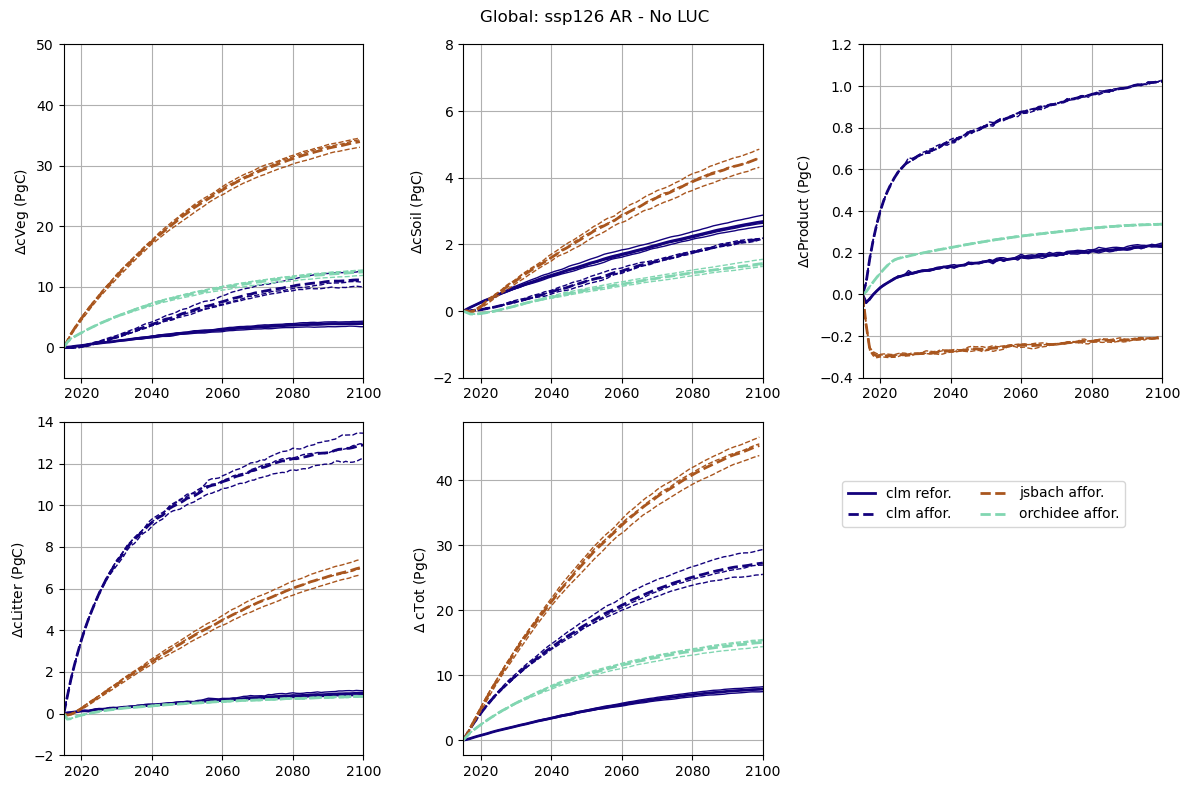

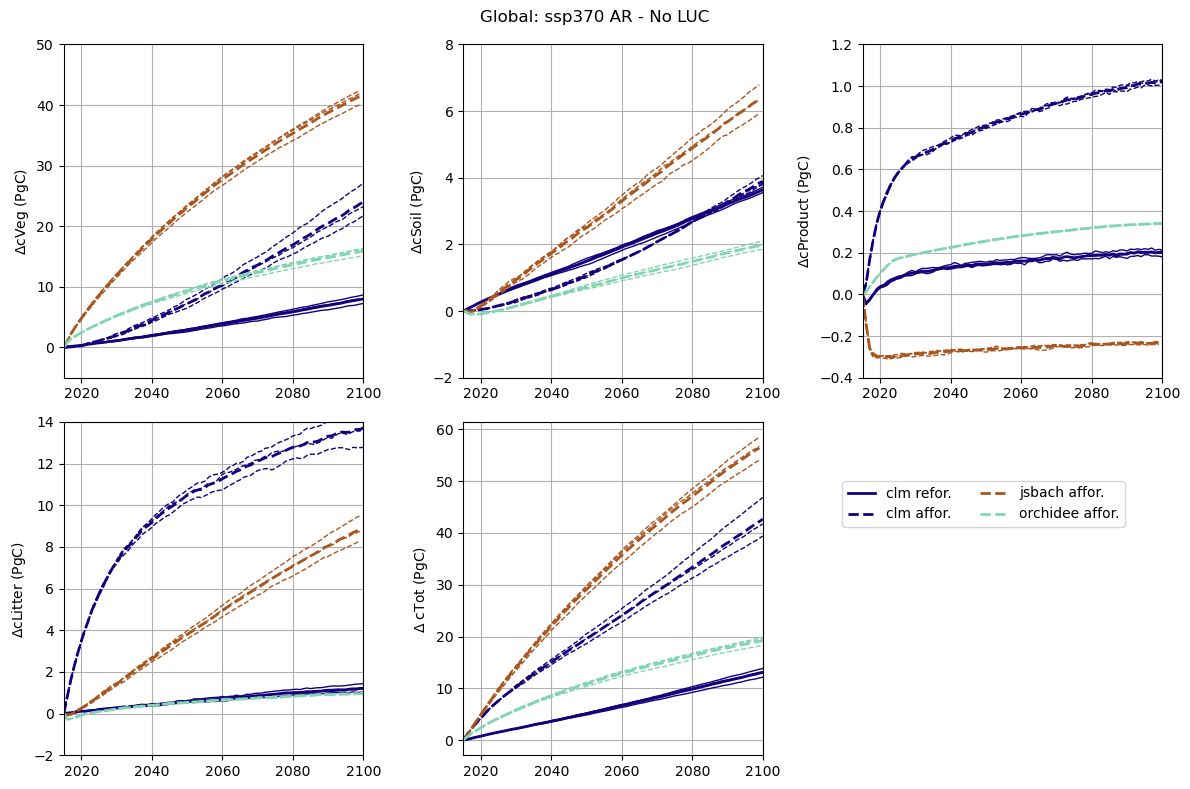

In [27]:
# PLOT BOTH AG to AFFORESTATION AND REFORESTATION ON THE SAME PLOT

MODELS=['clm','jsbach','orchidee']

landuse_title=['nolucaff','noluc', \
               ' Agriculture to natural', \
               ' Agriculture to afforestation', ' Natural to afforestation']

ARTITLES=['reforestation','afforestation']
linestyles_AR = {title: [] for title in ARTITLES}
linestyles_AR['reforestation'] = '-'
linestyles_AR['afforestation'] = '--'

plotdiff = True
plot_all = True

print(MODELS)

CTOT = {landuse: {lsm: {ssp: {esm: [] for esm in ESMS} for ssp in SSPS} 
                  for lsm in MODELS} for landuse in LANDUSES}

ymin = (-5, -2, -0.4, -2, -5)
ymax = (50, 8, 1.2, 14, 45)
for region in REGIONS[0:1]:
    i1=2
     
    for ssp in SSPS:

        #Set up plotting stuff
        #Each SSP scenario has a new figure
        fig2,axes2=plt.subplots(2,3, figsize=[12,8])
        if(plotdiff):
            fig2.suptitle(region+': '+ssp+' AR - No LUC',fontsize=12)
        else:
            fig2.suptitle(region+ssp,fontsize=12)
        i1+=1
        ix=0
        iy=0    

        ivar = 0

        for var in VARIABLES[:-1]:

            # set axes
            ax=axes2[iy,ix]
            ax.set_ylabel(r'$\Delta$' +var+' (PgC) ',fontsize=10)
            ax.set_xlim([2015,2100])
            ax.set_ylim([ymin[ivar],ymax[ivar]])
            ivar+=1
            ax.grid(True) 
        
            for model in MODELS:
                if model=='jsbach':
                    endyear=nyears-1
                else:
                    endyear=nyears
                if model=='jules': 
                    s0='nolucaff'
                else: 
                    s0='noluc'
 
                if (variable_exists[var][model]):

                    if (plotdiff):
                        #print(var,model,region,ssp)
                        if (landuse_exists[model]['agtonat']): 
                            plot_luc_R=((LU_SCENARIO_MEAN[var][model][region]['agtonat'][ssp])- \
                                        (LU_SCENARIO_MEAN[var][model][region]['agtonat'][ssp])[0])- \
                                        ((LU_SCENARIO_MEAN[var][model][region][s0][ssp])- \
                                        (LU_SCENARIO_MEAN[var][model][region][s0][ssp])[0])
                            if plot_all:
                                for esm in ESMS:
                                    plot_clim=((LU_SCENARIO_ALL[var][model][region]['agtonat'][esm][ssp])- \
                                              (LU_SCENARIO_ALL[var][model][region]['agtonat'][esm][ssp])[0]) - \
                                              ((LU_SCENARIO_ALL[var][model][region][s0][esm][ssp])- \
                                              (LU_SCENARIO_ALL[var][model][region][s0][esm][ssp])[0])
                                    ax.plot(years[:endyear], plot_clim, c=colors[model], 
                                            ls=linestyles_AR['reforestation'], lw=1)
                        
                        if (landuse_exists[model]['agtoaff']): 
                            plot_luc_A=((LU_SCENARIO_MEAN[var][model][region]['agtoaff'][ssp])- \
                                        (LU_SCENARIO_MEAN[var][model][region]['agtoaff'][ssp])[0])- \
                                        ((LU_SCENARIO_MEAN[var][model][region][s0][ssp])- \
                                        (LU_SCENARIO_MEAN[var][model][region][s0][ssp])[0])
                            if plot_all:
                                for esm in ESMS:
                                    plot_clim=((LU_SCENARIO_ALL[var][model][region]['agtoaff'][esm][ssp])- \
                                              (LU_SCENARIO_ALL[var][model][region]['agtoaff'][esm][ssp])[0]) - \
                                              ((LU_SCENARIO_ALL[var][model][region][s0][esm][ssp])- \
                                              (LU_SCENARIO_ALL[var][model][region][s0][esm][ssp])[0])
                                    ax.plot(years[:endyear], plot_clim, c=colors[model], 
                                        ls=linestyles_AR['afforestation'], lw=1)                        
                    else:
                        plot_luc_R=((LU_SCENARIO_MEAN[var][model][region]['agtonat'][ssp])- \
                                    (LU_SCENARIO_MEAN[var][model][region]['agtonat'][ssp])[0])
                        plot_luc_A=((LU_SCENARIO_MEAN[var][model][region]['agtoaff'][ssp])- \
                                    (LU_SCENARIO_MEAN[var][model][region]['agtoaff'][ssp])[0])                        
                    if (landuse_exists[model]['agtonat']): 
                        ax.plot(years[:endyear], plot_luc_R, label=model+' natural regen',
                                c=colors[model],ls=linestyles_AR['reforestation'],lw=2)
                    if (landuse_exists[model]['agtoaff']):
                        ax.plot(years[:endyear], plot_luc_A, label=model+' AR',
                                c=colors[model],ls=linestyles_AR['afforestation'],lw=2)
                        #print(var,model,ssp,plot_luc[-1])

                        #m,b = np.polyfit(years[endyear-20:endyear-1],plot_noluc[-20:-1], 1)
                        #print(var,model,ssp,'slope over last 20 years:',m)
            ix+=1
            if ix==3:
                ix=0
                iy+=1

        #Plot the sum
        ax=axes2[iy,ix]
        ax.set_ylabel(r'$\Delta$ cTot (PgC) ',fontsize=10)
        ax.set_xlim([2015,2100])
        ax.grid(True) 
        for model in MODELS:
            if model=='jsbach':
                endyear=nyears-1
            else:
                endyear=nyears

            if model=='jules':
                s0='nolucaff'
            else: 
                s0='noluc'
            print('calc total:',model,landuse)
            ctot_luc_A=0
            ctot_luc_R=0
            ctot_noluc=0

            for var in VARIABLES[:-1]:

                if (variable_exists[var][model]):
                    ctot_noluc += np.array(LU_SCENARIO_MEAN[var][model][region][s0][ssp])                   

                    if landuse_exists[model]['agtonat']:
                        ctot_luc_R += np.array(LU_SCENARIO_MEAN[var][model][region]['agtonat'][ssp])

                    if landuse_exists[model]['agtoaff']:
                        ctot_luc_A += np.array(LU_SCENARIO_MEAN[var][model][region]['agtoaff'][ssp])
            
            for esm in ESMS:
                ctot_esm_noluc=0
                ctot_esm_A=0
                ctot_esm_R=0
                for var in VARIABLES[:-1]:

                    if (variable_exists[var][model]):
                        ctot_esm_noluc+=np.array(LU_SCENARIO_ALL[var][model][region][s0][esm][ssp])

                        if landuse_exists[model]['agtonat']:
                            ctot_esm_R+=np.array(LU_SCENARIO_ALL[var][model][region]['agtonat'][esm][ssp])
                        if landuse_exists[model]['agtoaff']:
                            ctot_esm_A+=np.array(LU_SCENARIO_ALL[var][model][region]['agtoaff'][esm][ssp])
            
                CTOT['noluc'][model][ssp][esm] = ctot_esm_noluc
                CTOT['agtonat'][model][ssp][esm] = ctot_esm_R
                CTOT['agtoaff'][model][ssp][esm] = ctot_esm_A
                del(ctot_esm_noluc)
                del(ctot_esm_A)
                del(ctot_esm_R)
            
            if plotdiff:
                if landuse_exists[model]['agtonat']:
                    ax.plot(years[:endyear], (ctot_luc_R-ctot_luc_R[0])-(ctot_noluc-ctot_noluc[0]), 
                                    label=model+' refor.',
                                    c=colors[model],ls=linestyles_AR['reforestation'],lw=2)
                    if plot_all:
                        for esm in ESMS:
                            ax.plot(years[:endyear], 
                                    (CTOT['agtonat'][model][ssp][esm]-CTOT['agtonat'][model][ssp][esm][0]) -\
                                    (CTOT['noluc'][model][ssp][esm]-CTOT['noluc'][model][ssp][esm][0]),
                                    c=colors[model], ls=linestyles_AR['reforestation'], lw=1)  
                          
                if landuse_exists[model]['agtoaff']:
                    ax.plot(years[:endyear], (ctot_luc_A-ctot_luc_A[0])-(ctot_noluc-ctot_noluc[0]), 
                                     label=model+' affor.',
                                    c=colors[model],ls=linestyles_AR['afforestation'],lw=2) 
                    if plot_all:
                        for esm in ESMS:
                            ax.plot(years[:endyear], 
                                    (CTOT['agtoaff'][model][ssp][esm]-CTOT['agtoaff'][model][ssp][esm][0]) -\
                                    (CTOT['noluc'][model][ssp][esm]-CTOT['noluc'][model][ssp][esm][0]),
                                    c=colors[model], ls=linestyles_AR['afforestation'], lw=1)                          
            else:
                if landuse_exists[model]['agtonat']:
                    ax.plot(years[:endyear], (ctot_luc_R-ctot_luc_R[0]), 
                                label=model+' refor.',
                                c=colors[model],ls=linestyles_AR['reforestation'],lw=2)
                if landuse_exists[model]['agtoaff']:
                    ax.plot(years[:endyear], (ctot_luc_A-ctot_lucA[0]), 
                                label=model+' affor.',
                                c=colors[model],ls=linestyles_AR['afforestation'],lw=2)                        
            #print('cTot:',model,ssp,(ctot_luc_R-ctot_luc_R[0])[-1])
            del(ctot_noluc)
            del(ctot_luc_A)
            del(ctot_luc_R)


        handles2,labels2 = ax.get_legend_handles_labels()
        ax=axes2[1,2]
        ax.remove()
        fig2.legend(handles2,labels2,ncol=2,loc='upper left',bbox_to_anchor=(0.7, 0.4),fontsize=10)
        fig2.tight_layout()
        if plotdiff:
            plt.savefig('/bdd/ESM2025/WP10/plots/cpools_agAR-noluc_'+region+'_'+ssp+'.png', format="png")
        else:
            plt.savefig('/bdd/ESM2025/WP10/plots/cpools_agAR_'+region+'_'+ssp+'.png', format="png")

['clm', 'jsbach', 'orchidee']
calc total: clm nattoaff
calc total: jsbach nattoaff
calc total: orchidee nattoaff
calc total: clm nattoaff
calc total: jsbach nattoaff
calc total: orchidee nattoaff


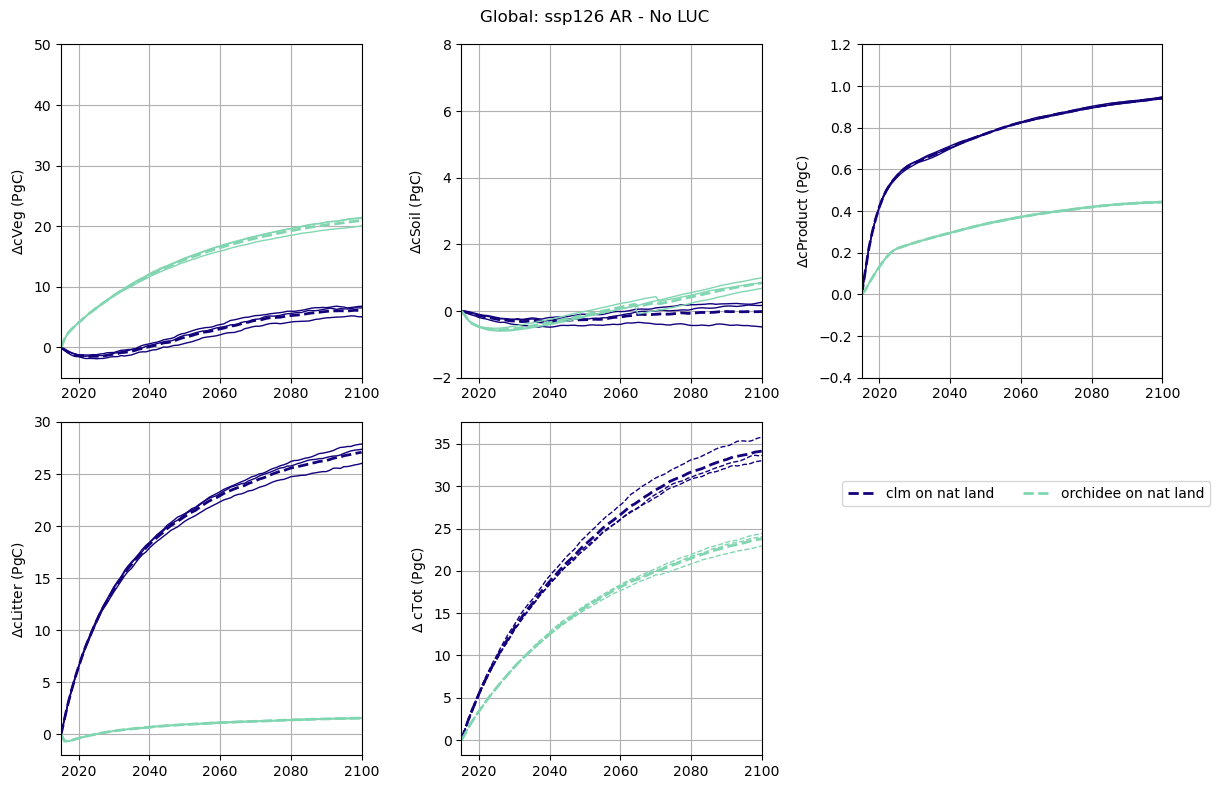

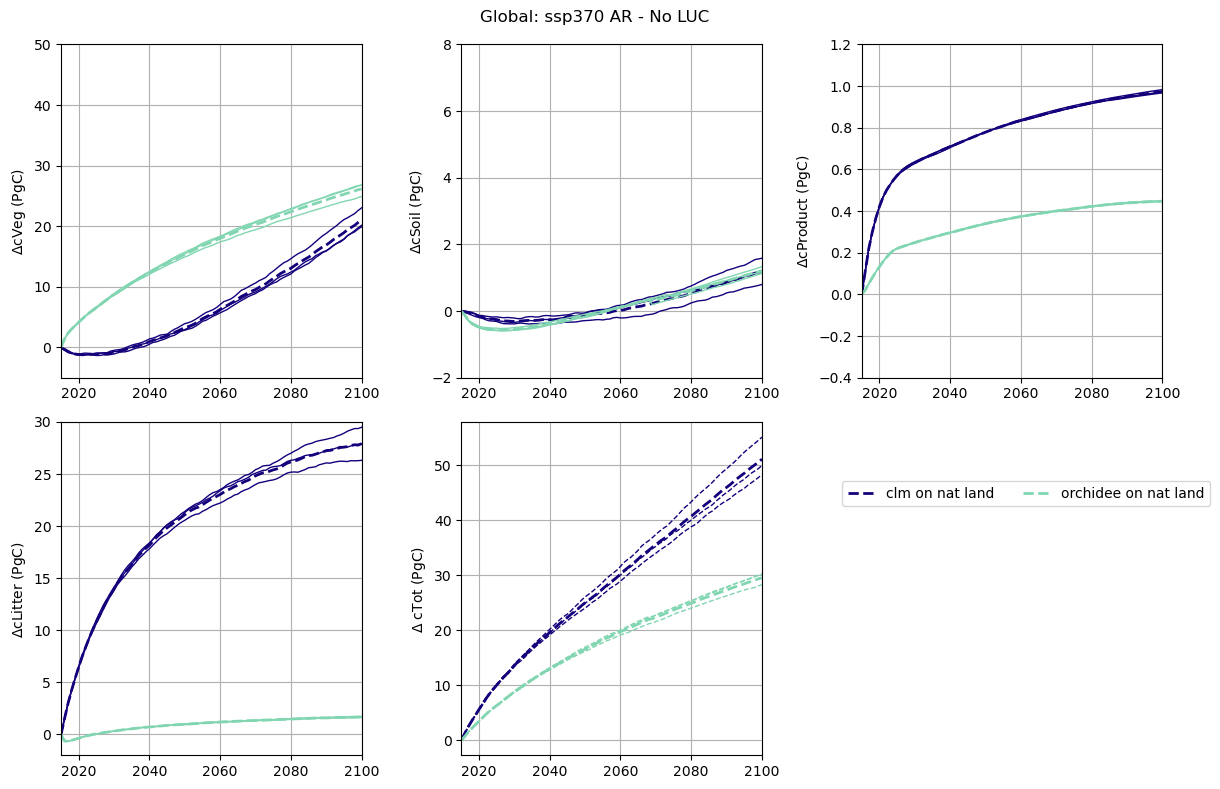

In [7]:
# PLOT NAT TO AFF ONLY

MODELS=['clm','jsbach','orchidee']

landuse_title=['nolucaff','noluc', \
               ' Agriculture to natural', \
               ' Agriculture to afforestation', ' Natural to afforestation']

ARTITLES=['reforestation','afforestation']
linestyles_AR = {title: [] for title in ARTITLES}
linestyles_AR['reforestation'] = '-'
linestyles_AR['afforestation'] = '--'

plotdiff = True
plot_all = True

print(MODELS)

ymin = (-5, -2, -0.4, -2, -5)
ymax = (50, 8, 1.2, 30, 45)
for region in REGIONS[0:1]:
    i1=2
     
    for ssp in SSPS:

        #Set up plotting stuff
        #Each SSP scenario has a new figure
        fig2,axes2=plt.subplots(2,3, figsize=[12,8])
        if(plotdiff):
            fig2.suptitle(region+': '+ssp+' AR - No LUC',fontsize=12)
        else:
            fig2.suptitle(region+ssp,fontsize=12)
        i1+=1
        ix=0
        iy=0    

        ivar = 0

        for var in VARIABLES[:-1]:

            # set axes
            ax=axes2[iy,ix]
            ax.set_ylabel(r'$\Delta$' +var+' (PgC) ',fontsize=10)
            ax.set_xlim([2015,2100])
            ax.set_ylim([ymin[ivar],ymax[ivar]])
            ivar+=1
            ax.grid(True) 
        
            for model in MODELS:
                if model=='jsbach':
                    endyear=nyears-1
                else:
                    endyear=nyears
                if model=='jules': 
                    s0='nolucaff'
                else: 
                    s0='noluc'
 
                if (variable_exists[var][model]):

                    if (plotdiff):
                        #print(var,model,region,ssp)
                        if (landuse_exists[model]['nattoaff']): 
                            plot_luc_A=((LU_SCENARIO_MEAN[var][model][region]['nattoaff'][ssp])- \
                                        (LU_SCENARIO_MEAN[var][model][region]['nattoaff'][ssp])[0])- \
                                        ((LU_SCENARIO_MEAN[var][model][region][s0][ssp])- \
                                        (LU_SCENARIO_MEAN[var][model][region][s0][ssp])[0])
                            if plot_all:
                                for esm in ESMS:
                                    plot_clim=((LU_SCENARIO_ALL[var][model][region]['nattoaff'][esm][ssp])- \
                                              (LU_SCENARIO_ALL[var][model][region]['nattoaff'][esm][ssp])[0]) - \
                                              ((LU_SCENARIO_ALL[var][model][region][s0][esm][ssp])- \
                                              (LU_SCENARIO_ALL[var][model][region][s0][esm][ssp])[0])
                                    ax.plot(years[:endyear], plot_clim, c=colors[model], 
                                            ls=linestyles_AR['reforestation'], lw=1)              
                    else:
                        plot_luc_A=((LU_SCENARIO_MEAN[var][model][region]['nattoaff'][ssp])- \
                                    (LU_SCENARIO_MEAN[var][model][region]['nattoaff'][ssp])[0])
                               
                    if (landuse_exists[model]['nattoaff']): 
                        ax.plot(years[:endyear], plot_luc_A, label=model+' on nat land',
                                c=colors[model],ls=linestyles_AR['afforestation'],lw=2)
                   
            ix+=1
            if ix==3:
                ix=0
                iy+=1

        #Plot the sum
        ax=axes2[iy,ix]
        ax.set_ylabel(r'$\Delta$ cTot (PgC) ',fontsize=10)
        ax.set_xlim([2015,2100])
        ax.grid(True) 
        for model in MODELS:
            if model=='jsbach':
                endyear=nyears-1
            else:
                endyear=nyears

            if model=='jules':
                s0='nolucaff'
            else: 
                s0='noluc'
            print('calc total:',model,landuse)
            ctot_luc_A=0
            ctot_luc_R=0
            ctot_noluc=0
            ctot_noluc1=0
            ctot_noluc2=0
            ctot_noluc3=0
            ctot_luc_A1=0
            ctot_luc_A2=0
            ctot_luc_A3=0            
            for var in VARIABLES[:-1]:

                if (variable_exists[var][model]):
                    ctot_noluc += np.array(LU_SCENARIO_MEAN[var][model][region][s0][ssp])
                    ctot_noluc1 += np.array(LU_SCENARIO_ALL[var][model][region][s0]['mpi-esm1-2-hr'][ssp])
                    ctot_noluc2 += np.array(LU_SCENARIO_ALL[var][model][region][s0]['ukesm1-0-ll'][ssp])
                    ctot_noluc3 += np.array(LU_SCENARIO_ALL[var][model][region][s0]['ipsl-cm6a-lr'][ssp])                     
                    if landuse_exists[model]['nattoaff']:
                        ctot_luc_A += np.array(LU_SCENARIO_MEAN[var][model][region]['nattoaff'][ssp])
                        ctot_luc_A1 += np.array(LU_SCENARIO_ALL[var][model][region]['nattoaff']['mpi-esm1-2-hr'][ssp])
                        ctot_luc_A2 += np.array(LU_SCENARIO_ALL[var][model][region]['nattoaff']['ukesm1-0-ll'][ssp]) 
                        ctot_luc_A3 += np.array(LU_SCENARIO_ALL[var][model][region]['nattoaff']['ipsl-cm6a-lr'][ssp]) 

            CTOT['nattoaff'][model][ssp][esm] = ctot_luc_A
            
            if plotdiff:
                if landuse_exists[model]['nattoaff']:
                    ax.plot(years[:endyear], (ctot_luc_A-ctot_luc_A[0])-(ctot_noluc-ctot_noluc[0]), 
                                    label=model+' on nat land',
                                    c=colors[model],ls=linestyles_AR['afforestation'],lw=2)
                    if plot_all:
                        ax.plot(years[:endyear], (ctot_luc_A1-ctot_luc_A1[0])-(ctot_noluc1-ctot_noluc1[0]),
                                c=colors[model], ls=linestyles_AR['afforestation'], lw=1)  
                        ax.plot(years[:endyear], (ctot_luc_A2-ctot_luc_A2[0])-(ctot_noluc2-ctot_noluc2[0]),
                                c=colors[model], ls=linestyles_AR['afforestation'], lw=1)  
                        ax.plot(years[:endyear], (ctot_luc_A3-ctot_luc_A3[0])-(ctot_noluc3-ctot_noluc3[0]),
                                c=colors[model], ls=linestyles_AR['afforestation'], lw=1)                          
                                          
            else:
                if landuse_exists[model]['nattoaff']:
                    ax.plot(years[:endyear], (ctot_luc_A-ctot_luc_A[0]), 
                                label=model+' on nat land',
                                c=colors[model],ls=linestyles_AR['afforestation'],lw=2)
                                  
            #print('cTot:',model,ssp,(ctot_luc_R-ctot_luc_R[0])[-1])
            del(ctot_noluc)
            del(ctot_luc_A)
            del(ctot_luc_R)


        handles2,labels2 = ax.get_legend_handles_labels()
        ax=axes2[1,2]
        ax.remove()
        fig2.legend(handles2,labels2,ncol=2,loc='upper left',bbox_to_anchor=(0.7, 0.4),fontsize=10)
        fig2.tight_layout()
        if plotdiff:
            plt.savefig('/bdd/ESM2025/WP10/plots/cpools_natAff-noluc_'+region+'_'+ssp+'.png', format="png")
        else:
            plt.savefig('/bdd/ESM2025/WP10/plots/cpools_natAff_'+region+'_'+ssp+'.png', format="png")

In [10]:
TIMESCALES = ['2015-2024','2040-2050','2090-2099']
DCVEG = {time: {landuse: {ssp: {lsm: [] for lsm in MODELS} for ssp in SSPS} 
                     for landuse in LANDUSES} for time in TIMESCALES}
#CTOT = {landuse: {lsm: {ssp: {esm: [] for esm in ESMS} for ssp in SSPS} 
#                  for lsm in MODELS} for landuse in LANDUSES}
#LANDUSES=['nolucaff','noluc','agtobio', 'agtonat', 'agtoaff', 'nattobio', 'nattoaff']

for landuse in LANDUSES[3:]:
    for ssp in SSPS:
        for lsm in MODELS:
            if landuse_exists[lsm][landuse]:
                print(CTOT[landuse][lsm][ssp])
                ens_mean_luc = average_dict(CTOT[landuse][lsm][ssp])
                ens_mean_noluc = average_dict(CTOT['noluc'][lsm][ssp])
                print(ens_mean_luc[0:20] )
                DCVEG['2015-2024'][landuse][ssp][lsm] = ens_mean_luc[0:20] - ens_mean_noluc[0:20]
                print('hello?')

{'mpi-esm1-2-hr': [], 'ukesm1-0-ll': [], 'ipsl-cm6a-lr': array([3130.90222785, 3134.09936213, 3137.62389511, 3141.01108891,
       3144.96219184, 3148.69152229, 3152.37388623, 3156.28058066,
       3160.28588281, 3163.88137371, 3167.07506882, 3171.39089103,
       3175.90986159, 3179.50123734, 3183.01470495, 3186.99026841,
       3190.99376443, 3195.08752869, 3198.92224106, 3203.02099932,
       3207.0052925 , 3210.75135865, 3214.54461433, 3218.18308624,
       3222.0657067 , 3225.87298584, 3229.46063639, 3233.3694027 ,
       3237.74772155, 3241.40643277, 3244.27812068, 3247.62251598,
       3251.46565019, 3255.46277708, 3259.06024027, 3262.4766677 ,
       3265.20563734, 3269.00287966, 3272.05235235, 3275.19443251,
       3278.59241189, 3281.47401034, 3284.6017886 , 3287.73737846,
       3290.31811162, 3292.93567223, 3296.24014198, 3300.06271759,
       3302.86216254, 3305.47448873, 3308.33666527, 3311.13310439,
       3313.3406771 , 3315.30458779, 3318.10158424, 3320.48003537,
     

IndexError: index 0 is out of bounds for axis 0 with size 0